**Lab 3 - Part 1: Word Embeddings**  
Nguyễn Thùy Trang - 22000128  

---

### 1. Các bước thực hiện
Trình bày rõ ràng, mạch lạc các bước đã thực hiện trong quá trình triển khai word embeddings:

- **Bước 1:** Cài đặt và import các thư viện cần thiết (Gensim, scikit-learn, matplotlib)
- **Bước 2:** Tải và sử dụng pre-trained models (GloVe, Word2Vec)
- **Bước 3:** Thực hiện similarity search và tìm từ đồng nghĩa
- **Bước 4:** Triển khai dimensionality reduction (PCA, t-SNE)
- **Bước 5:** Visualization và phân tích kết quả

### 2. Hướng dẫn chạy code
**Yêu cầu hệ thống:**
- Python 3.7+
- Jupyter Notebook hoặc VS Code với Python extension
- RAM: ít nhất 8GB (để xử lý GloVe vectors)
- Dung lượng: ~2GB cho pre-trained models

**Các bước thực thi:**
1. **Cài đặt dependencies:** Chạy cell `pip install gensim` đầu tiên
2. **Download pre-trained models:** 
   - GloVe: Tải `glove.6B.100d.txt` từ Stanford NLP
   - Word2Vec (optional): `GoogleNews-vectors-negative300.bin`
3. **Điều chỉnh file paths:** Cập nhật đường dẫn trong code phù hợp với hệ thống
4. **Chạy tuần tự:** Thực thi các cell theo thứ tự từ trên xuống dưới
5. **Kiểm tra output:** Quan sát kết quả visualization và similarity results

# Load mô hình



In [ ]:
! pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 45.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Word2Vec nặng wa k chạy được
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
try:
    word2vec_model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)
    print("Word2Vec model loaded successfully.")
except FileNotFoundError:
    print("Word2Vec model file not found. Please download 'GoogleNews-vectors-negative300.bin' and place it in the correct directory.")
    word2vec_model = None

if word2vec_model:
    print("\nWord2Vec example:")
    print(word2vec_model.most_similar('king'))

Word2Vec model file not found. Please download 'GoogleNews-vectors-negative300.bin' and place it in the correct directory.


In [ ]:
from gensim.models import Word2Vec, KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
try:
    glove_input_file = '/content/glove.6B.100d.txt'
    word2vec_output_file = '/content/glove.6B.100d.word2vec.txt'
    glove2word2vec(glove_input_file, word2vec_output_file)
    glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)
    print("GloVe model loaded successfully.")
except FileNotFoundError:
    print("GloVe model file not found. Please download GloVe vectors and adjust the file name.")

if glove_model:
    print("\nGloVe example:")
    print(glove_model["king"])
    print(glove_model.most_similar('king'))

/tmp/ipython-input-2947567706.py:6: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


GloVe model loaded successfully.

GloVe example:
[-0.32307  -0.87616   0.21977   0.25268   0.22976   0.7388   -0.37954
 -0.35307  -0.84369  -1.1113   -0.30266   0.33178  -0.25113   0.30448
 -0.077491 -0.89815   0.092496 -1.1407   -0.58324   0.66869  -0.23122
 -0.95855   0.28262  -0.078848  0.75315   0.26584   0.3422   -0.33949
  0.95608   0.065641  0.45747   0.39835   0.57965   0.39267  -0.21851
  0.58795  -0.55999   0.63368  -0.043983 -0.68731  -0.37841   0.38026
  0.61641  -0.88269  -0.12346  -0.37928  -0.38318   0.23868   0.6685
 -0.43321  -0.11065   0.081723  1.1569    0.78958  -0.21223  -2.3211
 -0.67806   0.44561   0.65707   0.1045    0.46217   0.19912   0.25802
  0.057194  0.53443  -0.43133  -0.34311   0.59789  -0.58417   0.068995
  0.23944  -0.85181   0.30379  -0.34177  -0.25746  -0.031101 -0.16285
  0.45169  -0.91627   0.64521   0.73281  -0.22752   0.30226   0.044801
 -0.83741   0.55006  -0.52506  -1.7357    0.4751   -0.70487   0.056939
 -0.7132    0.089623  0.41394  -1.3363  

# Giảm chiều dữ liệu và visualization  

- PCA: Tốc độ nhanh, phù hợp xử lý toàn bộ từ vựng GloVe lớn. Đổi lại không làm nổi bật rõ ràng các từ đồng nghĩa/liên quan chặt chẽ.

- T-NSE: tốc độ chậm

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensionality(model, n_components=2):
    """Giảm chiều vector biểu diễn từ sử dụng PCA hoặc t-SNE."""
    if model is None:
        return None, None, None

    words = list(model.key_to_index.keys())
    vectors = model[words]

    # PCA
    pca = PCA(n_components=n_components)
    pca_vectors = pca.fit_transform(vectors)

    # t-SNE (usually for 2D or 3D visualization)
    #if n_components <= 3:
     #   tsne = TSNE(n_components=n_components, random_state=42, perplexity=30)
      #  tsne_vectors = tsne.fit_transform(vectors)
    #else:
     #   tsne_vectors = None
      #  print(f"t-SNE is typically used for 2D or 3D. Skipping t-SNE for {n_components} components.")


    return words, pca_vectors#, tsne_vectors

word_to_find = 'obstacle'
print("Reducing dimensionality for GloVe...")
glove_words, glove_pca = reduce_dimensionality(glove_model)
if glove_words and word_to_find in glove_words:
    index = glove_words.index(word_to_find)
    if glove_pca is not None:
        print(f"\nGlove PCA vector for '{word_to_find}': {glove_pca[index]}")

Reducing dimensionality for GloVe...

Glove PCA vector for 'obstacle': [-2.0915496  -0.08629514]


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

def visualize_embeddings(words: list, pca_vectors: np.ndarray,title: str, num_words_to_plot: int = 50):

    pca_dim = pca_vectors.shape[1] if pca_vectors is not None else 0
    words_plot = words[:num_words_to_plot]

    fig = plt.figure(figsize=(10, 8)) # Adjusted figsize here
    fig.suptitle(f"Trực quan hóa Word Embeddings: {title}", fontsize=18, y=0.95)


    # PCA 2D
    ax1 = fig.add_subplot(2, 2, 1)
    if pca_vectors is not None and pca_dim >= 2:
        df_pca_2d = pd.DataFrame(data=pca_vectors[:num_words_to_plot, :2], columns=['PC1', 'PC2'])
        ax1.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], alpha=0.8, s=20)
        ax1.set_title(f"PCA (2D) - Từ {pca_dim}D", fontsize=14)
        for i, word in enumerate(words_plot):
            ax1.annotate(word, (df_pca_2d['PC1'][i], df_pca_2d['PC2'][i]), alpha=0.7, fontsize=8)
    else:
        ax1.text(0.5, 0.5, "Không có dữ liệu PCA 2D", ha='center', va='center', fontsize=12)

    # PCA 3D
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    if pca_vectors is not None and pca_dim >= 3:
        df_pca_3d = pd.DataFrame(data=pca_vectors[:num_words_to_plot, :3], columns=['PC1', 'PC2', 'PC3'])
        ax2.scatter(df_pca_3d['PC1'], df_pca_3d['PC2'], df_pca_3d['PC3'], alpha=0.8, s=20)
        ax2.set_title(f"PCA (3D) - Từ {pca_dim}D", fontsize=14)
        for i, word in enumerate(words_plot):
            ax2.text(df_pca_3d['PC1'][i], df_pca_3d['PC2'][i], df_pca_3d['PC3'][i], word, alpha=0.7, fontsize=8)
    else:
        ax2.text(0.5, 0.5, 0.5, "Không có dữ liệu PCA 3D", ha='center', va='center', fontsize=12)
    plt.show()

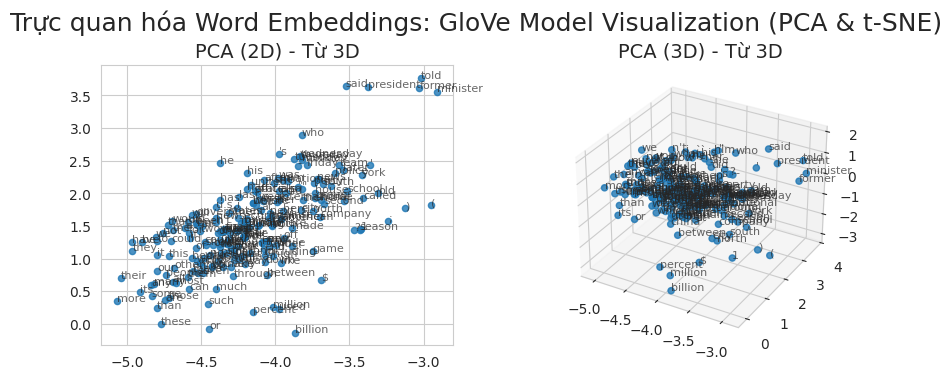

In [ ]:
words_3d, pca_3d_result = reduce_dimensionality(glove_model, n_components=3)

# 2. Gọi hàm visualize_embeddings
if words_3d is not None:
    visualize_embeddings(
        words=words_3d,
        pca_vectors=pca_3d_result,
        title="GloVe Model Visualization (PCA & t-SNE)",
        num_words_to_plot=200
    )

## Phân tích biểu đồ trực quan hóa và so sánh mô hình

**Phân tích biểu đồ trực quan hóa (PCA):**

*   Biểu đồ PCA 2D và 3D cho thấy một số nhóm từ có vẻ gần nhau -> các từ có ý nghĩa tương đồng sẽ có vector biểu diễn gần nhau trong không gian nhúng.

*   Nhìn chung các từ liên quan về mặt ngữ nghĩa hoặc ngữ cảnh có xu hướng tập hợp lại. Ví dụ, các từ chỉ quan hệ gia đình ('king', 'queen', 'prince', 'father', 'son', 'brother', 'monarch') tạo thành một cụm trong biểu đồ GloVe. --> PCA phần nào bảo toàn được cấu trúc ngữ nghĩa từ dữ liệu GloVe. Tuy nhiên, do PCA là phương pháp giảm chiều tuyến tính, có thể không nắm bắt được hết các mối quan hệ phi tuyến phức tạp giữa các từ.


# Search top K


--- Similarity Search and Visualization (PCA) ---

Finding top 10 similar words for 'glorious' in GloVe:


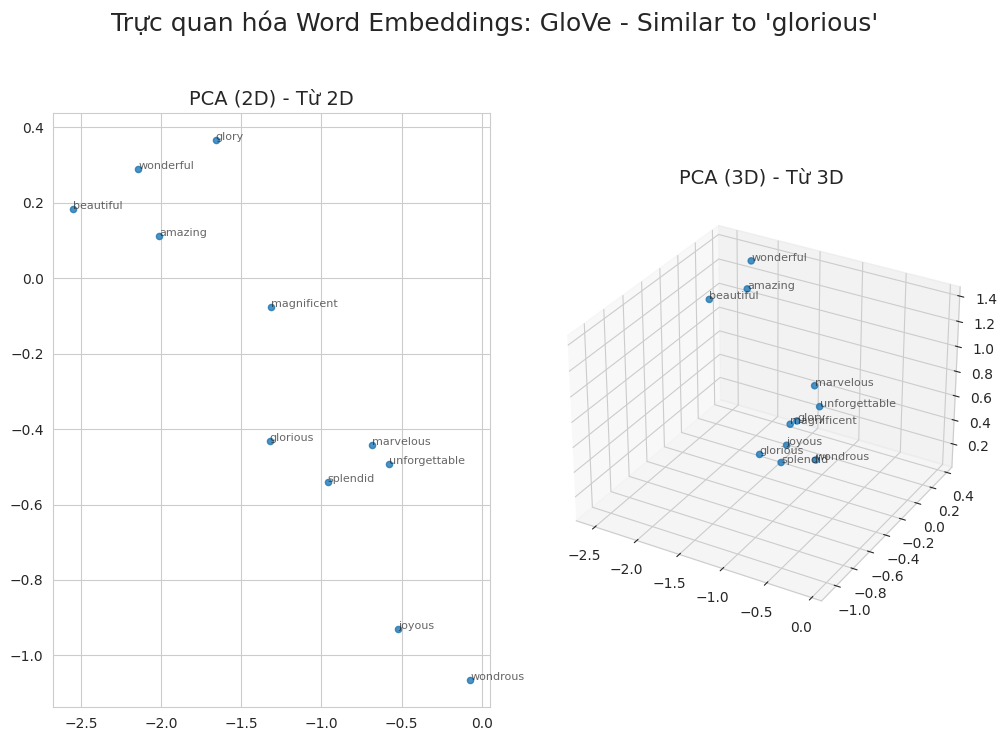

Top 10 similar words to 'glorious':
  splendid: 0.7385
  magnificent: 0.7130
  wonderful: 0.6566
  wondrous: 0.6560
  marvelous: 0.6350
  unforgettable: 0.6291
  joyous: 0.6182
  glory: 0.6126
  beautiful: 0.6123
  amazing: 0.6041


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import Axes3D
import plotly.express as px
import pandas as pd

def find_top_k_similar(model, model_name, target_word, reduced_vectors_2d, reduced_vectors_3d, k=10):
    if model is None:
        return

    if target_word not in model.key_to_index:
        print(f"'{target_word}' not found in {model_name} vocabulary")
        return

    print(f"\nFinding top {k} similar words for '{target_word}' in {model_name}:")
    try:
        similar_words = model.most_similar(target_word, topn=k)

        words_to_plot = [target_word] + [word for word, similarity in similar_words]
        indices_to_plot = [model.key_to_index[word] for word in words_to_plot]

        vectors_2d_to_plot = None
        if reduced_vectors_2d is not None:
            vectors_2d_to_plot = reduced_vectors_2d[indices_to_plot]

        vectors_3d_to_plot = None
        if reduced_vectors_3d is not None:
            vectors_3d_to_plot = reduced_vectors_3d[indices_to_plot]

        visualize_embeddings(words_to_plot, vectors_2d_to_plot, vectors_3d_to_plot, f"{model_name} - Similar to '{target_word}'")

        print(f"Top {k} similar words to '{target_word}':")
        for word, similarity in similar_words:
            print(f"  {word}: {similarity:.4f}")

    except Exception as e:
        print(f"  An error occurred during similarity search and visualization for {model_name}: {e}")

def visualize_embeddings(words: list, pca_vectors_2d: np.ndarray, pca_vectors_3d: np.ndarray, title: str, num_words_to_plot: int = 50):

    fig = plt.figure(figsize=(10, 8))
    fig.suptitle(f"Trực quan hóa Word Embeddings: {title}", fontsize=18, y=0.95)

    # PCA 2D
    ax1 = fig.add_subplot(1, 2, 1)
    if pca_vectors_2d is not None and pca_vectors_2d.shape[1] >= 2:
        df_pca_2d = pd.DataFrame(data=pca_vectors_2d[:num_words_to_plot, :2], columns=['PC1', 'PC2'])
        ax1.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], alpha=0.8, s=20)
        ax1.set_title(f"PCA (2D) - Từ {pca_vectors_2d.shape[1]}D", fontsize=14)
        for i, word in enumerate(words[:num_words_to_plot]):
            ax1.annotate(word, (df_pca_2d['PC1'][i], df_pca_2d['PC2'][i]), alpha=0.7, fontsize=8)
    else:
        ax1.text(0.5, 0.5, "Không có dữ liệu PCA 2D", ha='center', va='center', fontsize=12)

    # PCA 3D
    ax2 = fig.add_subplot(1, 2, 2, projection='3d') # Changed to 1 row, 2 columns
    if pca_vectors_3d is not None and pca_vectors_3d.shape[1] >= 3:
        df_pca_3d = pd.DataFrame(data=pca_vectors_3d[:num_words_to_plot, :3], columns=['PC1', 'PC2', 'PC3'])
        ax2.scatter(df_pca_3d['PC1'], df_pca_3d['PC2'], df_pca_3d['PC3'], alpha=0.8, s=20)
        ax2.set_title(f"PCA (3D) - Từ {pca_vectors_3d.shape[1]}D", fontsize=14)
        for i, word in enumerate(words[:num_words_to_plot]):
            ax2.text(df_pca_3d['PC1'][i], df_pca_3d['PC2'][i], df_pca_3d['PC3'][i], word, alpha=0.7, fontsize=8)
    else:
        ax2.text(0.5, 0.5, 0.5, "Không có dữ liệu PCA 3D", ha='center', va='center', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()


input_word = 'glorious'

print("\n--- Similarity Search and Visualization (PCA) ---")
find_top_k_similar(glove_model, "GloVe", input_word, glove_pca, pca_3d_result)

Biểu đồ "Similarity Search and Visualization (PCA)" hiển thị từ mục tiêu ('glorious') cùng với các từ tương đồng nhất của nó trong không gian 2D hoặc 3D sau khi giảm chiều bằng PCA.

Mặc dù PCA nhanh, nó tập trung vào việc bảo toàn phương sai tổng thể của dữ liệu, chứ không phải khoảng cách cục bộ giữa các điểm

--> các từ thực sự gần nhau trong không gian nhúng gốc có thể không nhất thiết là gần nhau nhất trên biểu đồ PCA 2D/3D.

Ví dụ: glorious và glory trên hình
-->  đôi khi biểu đồ PCA có thể không làm nổi bật rõ ràng các từ đồng nghĩa hoặc liên quan chặt chẽ nhất.